<a href="https://colab.research.google.com/github/NadhaKaleel/northstar-analytics/blob/main/notebooks/02_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Libraries installed and loaded successfully!"
[1] "All files loaded successfully from local session storage!"
  mean_distance sd_distance mean_rating mean_cost total_overrides
1      13.90932    7.477907    3.864679  12.84129             921
  failure_rate_pct
1         13.89474


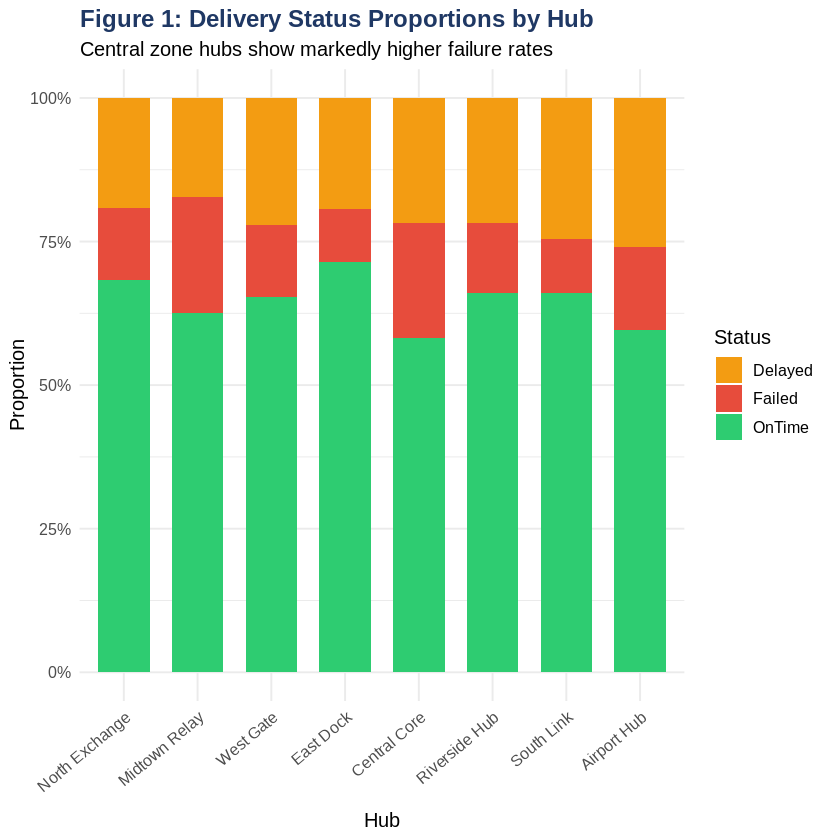

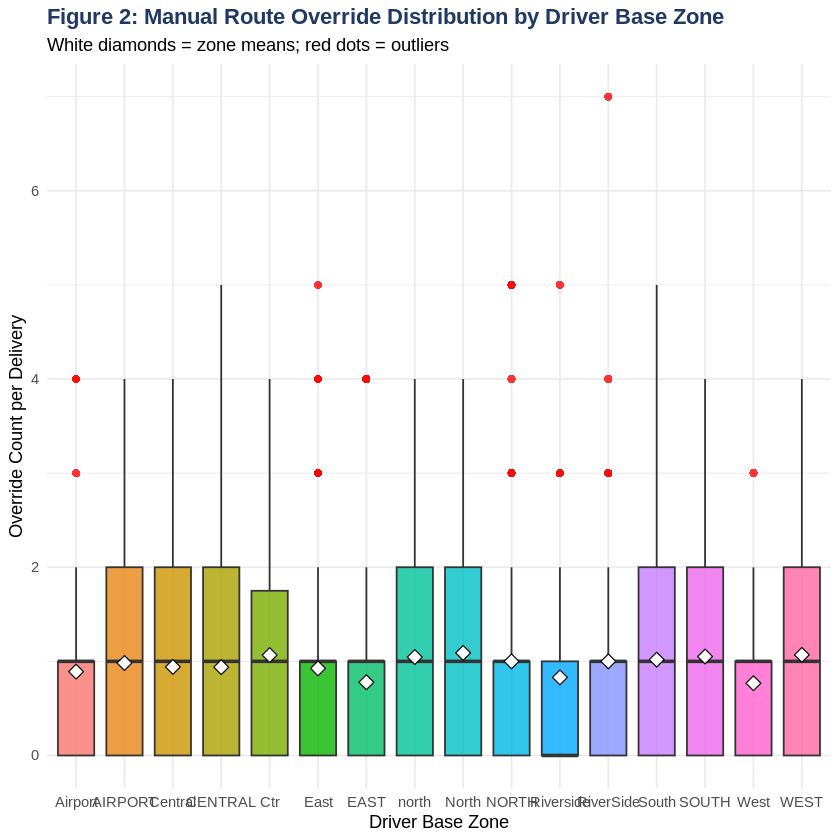

`geom_smooth()` using formula = 'y ~ x'


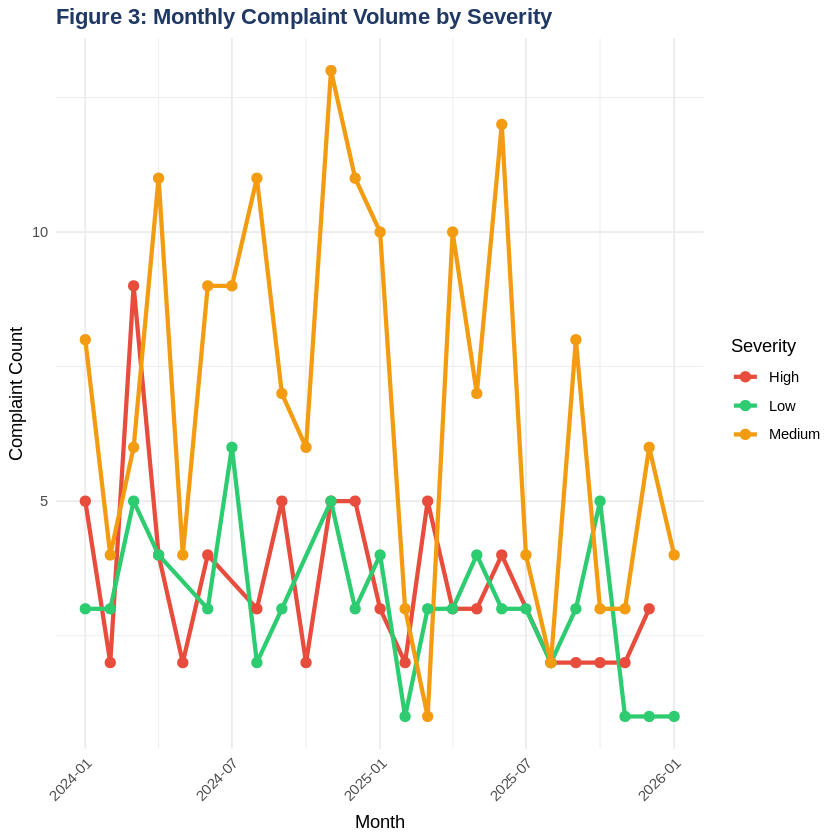

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



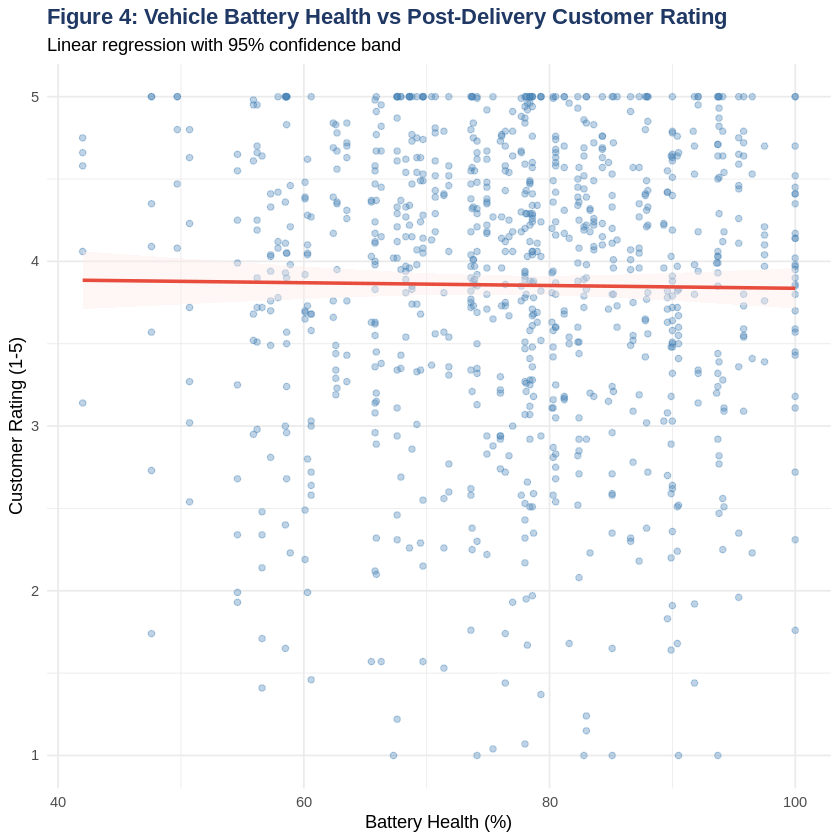

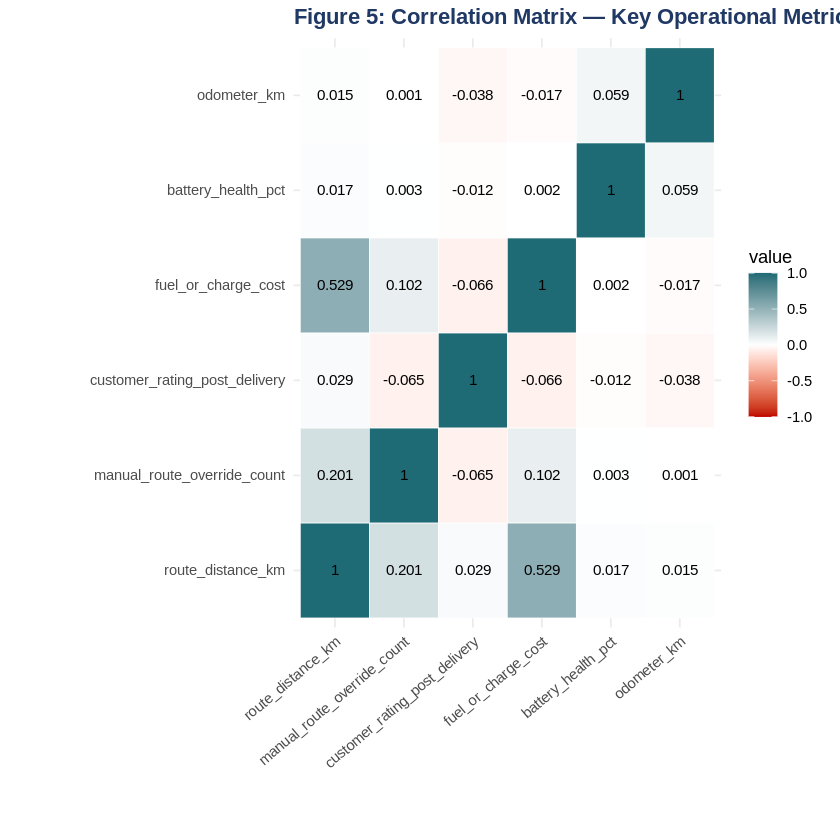

In [17]:
# Combined installation for all necessary analytics tools
install.packages(c('dplyr', 'ggplot2', 'lubridate', 'scales', 'stringr', 'sqldf'))

# Load them all at once
library(dplyr)
library(ggplot2)
library(lubridate)
library(scales)
library(stringr)
library(sqldf)

print("Libraries installed and loaded successfully!")

# 2. Define the path (Since they are uploaded to the sidebar, use './')
path <- "./"

# 3. Load files
# Using stringsAsFactors=FALSE is a good practice for older R versions
orders     <- read.csv(paste0(path, "orders.csv"))
deliveries <- read.csv(paste0(path, "deliveries.csv"))
customers  <- read.csv(paste0(path, "customers.csv"))
drivers    <- read.csv(paste0(path, "drivers.csv"))
vehicles   <- read.csv(paste0(path, "vehicles.csv"))
hubs       <- read.csv(paste0(path, "hubs.csv"))
incidents  <- read.csv(paste0(path, "incidents.csv"))
complaints <- read.csv(paste0(path, "complaints.csv"))
app_events <- read.csv(paste0(path, "app_events.csv"))

print("All files loaded successfully from local session storage!")

library(dplyr)

# Parse datetimes properly
deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time, format="%Y-%m-%d %H:%M:%S")
deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at, format="%Y-%m-%d %H:%M:%S")
complaints$created_at <- as.POSIXct(complaints$created_at, format="%Y-%m-%d %H:%M:%S")

# Feature engineering
deliveries <- deliveries %>%
  mutate(
    duration_hrs = as.numeric(difftime(delivery_completed_at, dispatch_time, units = "hours")),

    # Avoid division by zero
    cost_per_km = ifelse(route_distance_km == 0, NA,
                         fuel_or_charge_cost / route_distance_km),

    is_failed = as.integer(delivery_status == "Failed")
  )

# Summary statistics
deliveries %>%
  summarise(
    mean_distance    = mean(route_distance_km, na.rm = TRUE),
    sd_distance      = sd(route_distance_km, na.rm = TRUE),
    mean_rating      = mean(customer_rating_post_delivery, na.rm = TRUE),
    mean_cost        = mean(fuel_or_charge_cost, na.rm = TRUE),
    total_overrides  = sum(manual_route_override_count, na.rm = TRUE),
    failure_rate_pct = mean(is_failed, na.rm = TRUE) * 100
  ) %>%
  print()

del_hub <- deliveries %>% left_join(hubs, by='hub_id')

ggplot(del_hub, aes(x=reorder(hub_name,-table(hub_name)[hub_name]), fill=delivery_status)) +
 geom_bar(position='fill', width=0.7) +
 scale_y_continuous(labels=percent_format()) +
 scale_fill_manual(values=c('OnTime'='#2ECC71','Delayed'='#F39C12','Failed'='#E74C3C')) +
 labs(title='Figure 1: Delivery Status Proportions by Hub',
      subtitle='Central zone hubs show markedly higher failure rates',
      x='Hub', y='Proportion', fill='Status') +
 theme_minimal(base_size=12) +
 theme(axis.text.x=element_text(angle=40,hjust=1),
       plot.title=element_text(face='bold',color='#1F3864'))

       del_drv <- deliveries %>% left_join(drivers, by='driver_id')

ggplot(del_drv, aes(x=base_zone, y=manual_route_override_count, fill=base_zone)) +
 geom_boxplot(outlier.colour='red', outlier.shape=16, outlier.size=2, alpha=0.8) +
 stat_summary(fun=mean, geom='point', shape=23, size=3, fill='white') +
 labs(title='Figure 2: Manual Route Override Distribution by Driver Base Zone',
      subtitle='White diamonds = zone means; red dots = outliers',
      x='Driver Base Zone', y='Override Count per Delivery') +
 theme_minimal() + theme(legend.position='none',
       plot.title=element_text(face='bold',color='#1F3864'))

complaint_trend <- complaints %>%
 filter(!is.na(created_at)) %>%
 mutate(month = floor_date(created_at, 'month')) %>%
 group_by(month, severity) %>%
 summarise(count=n(), .groups='drop')

ggplot(complaint_trend, aes(x=month, y=count, colour=severity, group=severity)) +
 geom_line(linewidth=1.2) + geom_point(size=2.5) +
 scale_colour_manual(values=c('High'='#E74C3C','Medium'='#F39C12',
                               'Low'='#2ECC71','Critical'='#8E44AD')) +
 labs(title='Figure 3: Monthly Complaint Volume by Severity',
      x='Month', y='Complaint Count', colour='Severity') +
 theme_minimal() + theme(axis.text.x=element_text(angle=45,hjust=1),
       plot.title=element_text(face='bold',color='#1F3864'))

       del_veh <- deliveries %>% left_join(vehicles, by='vehicle_id') %>%
 filter(!is.na(battery_health_pct), !is.na(customer_rating_post_delivery))

ggplot(del_veh, aes(x=battery_health_pct, y=customer_rating_post_delivery)) +
 geom_point(alpha=0.35, colour='steelblue', size=1.5) +
 geom_smooth(method='lm', colour='#E74C3C', se=TRUE, fill='#FDECEA') +
 labs(title='Figure 4: Vehicle Battery Health vs Post-Delivery Customer Rating',
      subtitle='Linear regression with 95% confidence band',
      x='Battery Health (%)', y='Customer Rating (1-5)') +
 theme_minimal() + theme(plot.title=element_text(face='bold',color='#1F3864'))


       install.packages("reshape2")
library(reshape2)

library(reshape2)
num_data <- del_veh %>%
 select(route_distance_km, manual_route_override_count,
        customer_rating_post_delivery, fuel_or_charge_cost,
        battery_health_pct, odometer_km) %>% na.omit()

cor_mat  <- round(cor(num_data), 3)
cor_melt <- melt(cor_mat)

ggplot(cor_melt, aes(Var1, Var2, fill=value)) +
 geom_tile(colour='white') +
 geom_text(aes(label=value), size=3.2) +
 scale_fill_gradient2(low='#C00000',high='#1F6B75',mid='white',midpoint=0,limits=c(-1,1)) +
 labs(title='Figure 5: Correlation Matrix — Key Operational Metrics', x='', y='') +
 theme_minimal() + theme(axis.text.x=element_text(angle=40,hjust=1),
       plot.title=element_text(face='bold',color='#1F3864'))